# CLI v7 — NASA Noisy-Label Filter + Relative Baseline Features

**Project:** Predicting and Preventing Burnout Using Cognitive Load Analysis  
**Notebook:** 07 — Final model-selection experiment

---

## Purpose

This notebook is the final model-selection step before the Streamlit dashboard.
It combines the two strongest methodological contributions developed so far:

1. **NASA-TLX noisy-label filtering** (notebook 04):  
   Remove training segments where the participant's NASA-TLX questionnaire score
   strongly contradicts the design-based label. This gives the model a cleaner
   training signal by excluding the most ambiguous examples.

2. **Relative baseline-deviation features** (notebook 06):  
   Add delta (absolute deviation from personal resting baseline) and ratio
   (relative deviation) features for every original physiological feature.
   These give the cross-person model a representation that compensates for
   inter-individual physiological scale differences.

### Research question

> Does adding relative features on top of the filtered (v3) training data improve
> the CLI model's cross-person generalization?

### Three variants compared

All variants use the v3 noisy-label filter for training data.
The comparison isolates the effect of feature engineering only.

| Variant | Training data | Features |
|---|---|---|
| **A** | v3 filtered | Original features only |
| **B** | v3 filtered | Original + delta features |
| **C** | v3 filtered | Original + delta + ratio features |

### What does NOT change
- Model: GradientBoostingClassifier (n_estimators=100, same as v2)
- Evaluation: LOPO (leave-one-participant-out), 24 folds
- Labels: design-based (easy/relaxation = Low, hard = High)
- Data: Lab1 + Lab2 sessions, EDA + HRV + TEMP features only
- Test participant: always drawn from the **unfiltered** dataset

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, recall_score, roc_curve, auc as sklearn_auc,
)

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_ROOT     = Path('.')
SESSIONS      = ['Lab1', 'Lab2']
FEATURE_FILES = ['EDA_features', 'HRV_features', 'TEMP_features']

LOW_EXACT   = {'relaxation_video', 'video_baseline'}
LOW_SUFFIX  = '_easy'
HIGH_SUFFIX = '_hard'
RELAX_SEGS  = {'relaxation_video', 'video_baseline'}

# NASA-TLX filter thresholds (identical to notebook 04)
NASA_LOW_MAX  = 40   # High-label + NASA < 40  → remove from training
NASA_HIGH_MIN = 60   # Low-label  + NASA > 60  → remove from training

# Relative feature parameters (identical to notebook 06)
EPSILON    = 1e-6
RATIO_CLIP = 50

# Best model from v2 — unchanged throughout the project
BASE_MODEL = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)

# Output folder for exported artefacts
OUTPUTS_DIR = Path('outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Imports OK.')
print(f'Model        : {BASE_MODEL.__class__.__name__}  n_estimators=100  (same as v2)')
print(f'NASA filter  : Low + NASA > {NASA_HIGH_MIN} → remove   |   High + NASA < {NASA_LOW_MAX} → remove')
print(f'Relative feat: epsilon={EPSILON}   ratio clip ±{RATIO_CLIP}')
print(f'Output folder: {OUTPUTS_DIR.resolve()}')

Imports OK.
Model        : GradientBoostingClassifier  n_estimators=100  (same as v2)
NASA filter  : Low + NASA > 60 → remove   |   High + NASA < 40 → remove
Relative feat: epsilon=1e-06   ratio clip ±50
Output folder: C:\ForthYear\final project\UNIVERSE\outputs


---
## Step 1 — Load Feature Dataset

**What:** Load the pre-computed windowed feature files for all participants across Lab1 and Lab2 sessions.

**Why:** The feature files (`EDA_features`, `HRV_features`, `TEMP_features`) are the same
input used in all prior notebooks. Loading the full unfiltered dataset first is important
because the relative feature baselines (Step 3) must be computed on all windows,
including the ones that will later be filtered from training.

**How it supports the project goal:** A complete, unfiltered load ensures that no information
about the test participant's task windows accidentally leaks into the baseline computation.

In [2]:
def segment_to_label(segment_name):
    name = segment_name.lower()
    if name in LOW_EXACT or name.endswith(LOW_SUFFIX):
        return 0, 'Low'
    if name.endswith(HIGH_SUFFIX):
        return 1, 'High'
    return None, None


def load_segment(seg_dir, pid, session):
    seg_name = seg_dir.name
    label, load_level = segment_to_label(seg_name)
    if label is None:
        return None
    dfs = []
    for feat_name in FEATURE_FILES:
        fpath = seg_dir / f'{feat_name}.pickle'
        if not fpath.exists():
            return None
        with open(fpath, 'rb') as f:
            feat_df = pickle.load(f)
        if not isinstance(feat_df, pd.DataFrame):
            feat_df = pd.DataFrame(feat_df)
        dfs.append(feat_df.reset_index(drop=True))
    combined = pd.concat(dfs, axis=1)
    combined['label']          = label
    combined['load_level']     = load_level
    combined['participant_id'] = pid
    combined['session']        = session
    combined['segment']        = seg_name
    combined['window_idx']     = range(len(combined))
    return combined


def load_all_features():
    all_segs = []
    for pdir in sorted(DATA_ROOT.glob('UN_*')):
        if not pdir.is_dir():
            continue
        for session in SESSIONS:
            fp = pdir / session / 'Features'
            if not fp.exists():
                continue
            for sd in sorted(d for d in fp.iterdir() if d.is_dir()):
                df = load_segment(sd, pdir.name, session)
                if df is not None:
                    all_segs.append(df)
    return pd.concat(all_segs, ignore_index=True)


dataset = load_all_features()

META_COLS    = ['label', 'load_level', 'participant_id', 'session', 'segment', 'window_idx']
FEATURE_COLS = [c for c in dataset.columns if c not in META_COLS]

# Fill NaN windows with global column median (same strategy as all prior notebooks)
nan_count = dataset[FEATURE_COLS].isnull().sum().sum()
dataset[FEATURE_COLS] = dataset[FEATURE_COLS].fillna(dataset[FEATURE_COLS].median())

print(f'Dataset (full, unfiltered): {dataset.shape[0]:,} windows  |  {len(FEATURE_COLS)} features')
print(f'Participants: {dataset["participant_id"].nunique()}  |  NaN cells filled: {nan_count}')
print()
print('Class balance (before any filtering):')
print(dataset['load_level'].value_counts().to_frame('windows').to_string())

Dataset (full, unfiltered): 18,659 windows  |  10 features
Participants: 24  |  NaN cells filled: 54

Class balance (before any filtering):
            windows
load_level         
Low           10330
High           8329


---
## Step 2 — NASA-TLX Noisy-Label Filtering

**What:** Load the NASA-TLX questionnaire scores from each participant's `Task_Labels.csv`
and remove training segments where the design-based label strongly contradicts the
participant's self-reported cognitive experience.

**Why:** Design-based labels (easy/hard) reflect task difficulty, not necessarily perceived
difficulty. A participant who finds an "easy" task genuinely demanding (NASA > 60)
provides a physiological signal that contradicts the Low label — training on that example
injects noise. Removing the most contradicting segments produces a cleaner training set
without changing the label scheme.

**Important:** This is a conservative **quality-control step**, not relabeling.
- We do **not** assign new labels to any segment.
- We only remove segments where the contradiction is unambiguous (NASA > 60 or < 40).
- Segments with no NASA match are always kept ("when in doubt, keep").
- The **test participant's data is never filtered** — the filter is a training-data
  improvement only, applied within each LOPO fold to the 23 training participants.

**Segment name mapping:**  
The Features folder uses `relaxation_video`; the Task_Labels CSV uses `video_baseline`
for the same segment. One explicit mapping is applied before matching:
```
relaxation_video  →  video_baseline
```

In [3]:
LAB_KEEP = ['Task', 'Weighted Nasa Score']
SEGMENT_NAME_MAP = {'relaxation_video': 'video_baseline'}

def normalize_segment_name(name):
    """Map Features folder segment name to Task_Labels.csv Task name."""
    return SEGMENT_NAME_MAP.get(name.lower(), name.lower())


nasa_frames, nasa_load_log = [], []

for pdir in sorted(DATA_ROOT.glob('UN_*')):
    pid = pdir.name
    for session in SESSIONS:
        fpath = pdir / session / 'Task_Labels.csv'
        if not fpath.exists():
            nasa_load_log.append({'participant_id': pid, 'session': session, 'status': 'missing'})
            continue
        try:
            df = pd.read_csv(fpath)
            if 'Weighted Nasa Score' not in df.columns:
                nasa_load_log.append({'participant_id': pid, 'session': session, 'status': 'missing column'})
                continue
            df = df[[c for c in LAB_KEEP if c in df.columns]].copy()
            df['participant_id'] = pid
            df['session']        = session
            df['task_key']       = df['Task'].str.lower().str.strip()
            df['Weighted Nasa Score'] = pd.to_numeric(df['Weighted Nasa Score'], errors='coerce')
            nasa_frames.append(df)
            nasa_load_log.append({'participant_id': pid, 'session': session,
                                   'status': 'ok', 'n_tasks': len(df)})
        except Exception as e:
            nasa_load_log.append({'participant_id': pid, 'session': session, 'status': f'error: {e}'})

nasa_df = pd.concat(nasa_frames, ignore_index=True) if nasa_frames else pd.DataFrame()
log_df  = pd.DataFrame(nasa_load_log)

n_ok      = (log_df['status'] == 'ok').sum()
n_missing = (log_df['status'] != 'ok').sum()
print(f'Task_Labels.csv loaded: {n_ok} files  |  missing/error: {n_missing}')
print(f'Total NASA rows: {len(nasa_df)}  |  score range: {nasa_df["Weighted Nasa Score"].min():.0f}–{nasa_df["Weighted Nasa Score"].max():.0f}')
if n_missing > 0:
    print('\nFiles not loaded:')
    print(log_df[log_df['status'] != 'ok'][['participant_id','session','status']].to_string(index=False))

Task_Labels.csv loaded: 46 files  |  missing/error: 2
Total NASA rows: 411  |  score range: 0–99

Files not loaded:
participant_id session  status
        UN_112    Lab2 missing
        UN_120    Lab2 missing


In [4]:
# Build NASA lookup: (participant_id, session, task_key) → Weighted NASA Score
nasa_lookup = (
    nasa_df.dropna(subset=['Weighted Nasa Score'])
           .set_index(['participant_id', 'session', 'task_key'])['Weighted Nasa Score']
           .to_dict()
)

# Match each unique segment in the dataset to its NASA score
seg_index = (
    dataset.drop_duplicates(subset=['participant_id', 'session', 'segment'])
           [['participant_id', 'session', 'segment', 'label', 'load_level']].copy()
)
seg_index['task_key']   = seg_index['segment'].apply(normalize_segment_name)
seg_index['nasa_score'] = seg_index.apply(
    lambda r: nasa_lookup.get((r['participant_id'], r['session'], r['task_key'])), axis=1
)

n_matched   = seg_index['nasa_score'].notna().sum()
n_unmatched = seg_index['nasa_score'].isna().sum()
n_total_seg = len(seg_index)

print(f'Segments with NASA match  : {n_matched} / {n_total_seg}  ({100*n_matched/n_total_seg:.1f}%)')
print(f'Segments without match    : {n_unmatched} — these are always kept')
print()

# Identify noisy segments
is_noisy_low  = (seg_index['label'] == 0) & seg_index['nasa_score'].notna() & (seg_index['nasa_score'] > NASA_HIGH_MIN)
is_noisy_high = (seg_index['label'] == 1) & seg_index['nasa_score'].notna() & (seg_index['nasa_score'] < NASA_LOW_MAX)
is_noisy      = is_noisy_low | is_noisy_high

noisy_keys = set(
    zip(seg_index.loc[is_noisy, 'participant_id'],
        seg_index.loc[is_noisy, 'session'],
        seg_index.loc[is_noisy, 'segment'])
)

print(f'Noisy Low  (Low label + NASA > {NASA_HIGH_MIN}): {is_noisy_low.sum()} segments')
print(f'Noisy High (High label + NASA < {NASA_LOW_MAX}): {is_noisy_high.sum()} segments')
print(f'Total noisy segments to remove from training : {is_noisy.sum()}')
print()

# Apply filter
keep_mask  = ~dataset.apply(
    lambda r: (r['participant_id'], r['session'], r['segment']) in noisy_keys, axis=1
)
dataset_v3 = dataset[keep_mask].copy()

n_v2 = len(dataset)
n_v3 = len(dataset_v3)
n_segs_v2 = dataset.drop_duplicates(subset=['participant_id','session','segment']).shape[0]
n_segs_v3 = dataset_v3.drop_duplicates(subset=['participant_id','session','segment']).shape[0]

print('Filtering result:')
print(f'  Unfiltered (v2): {n_v2:,} windows  |  {n_segs_v2} segments')
print(f'  Filtered   (v3): {n_v3:,} windows  |  {n_segs_v3} segments')
print(f'  Retention: {100*n_v3/n_v2:.1f}%  |  Removed: {n_v2-n_v3:,} windows  ({is_noisy.sum()} segments)')
print()
print('Class balance AFTER filter (v3 training source):')
print(dataset_v3['load_level'].value_counts().to_frame('windows').to_string())

Segments with NASA match  : 406 / 407  (99.8%)
Segments without match    : 1 — these are always kept

Noisy Low  (Low label + NASA > 60): 78 segments
Noisy High (High label + NASA < 40): 18 segments
Total noisy segments to remove from training : 96

Filtering result:
  Unfiltered (v2): 18,659 windows  |  407 segments
  Filtered   (v3): 14,292 windows  |  311 segments
  Retention: 76.6%  |  Removed: 4,367 windows  (96 segments)

Class balance AFTER filter (v3 training source):
            windows
load_level         
High           7532
Low            6760


---
## Step 3 — Relative Baseline-Deviation Features

**What:** For every original physiological feature X, compute two additional features:
- **Delta:** `X_delta = X − personal_baseline_mean` — absolute deviation from rest
- **Ratio:** `X_ratio = clip(X / (personal_baseline_mean + ε), −50, 50)` — relative deviation

**Why:** The GBT model trains on 23 participants and tests on 1 unseen participant.
A split threshold such as "EDA_mean > 3.2" may work for most participants but fail for
the test participant if their resting EDA is 5.0 (different physiological baseline).
Delta and ratio features express every window relative to that participant's own resting
level — a value of 0 (delta) or 1 (ratio) means the person is at their personal baseline,
regardless of their absolute physiological level.

**Baseline source:**  
For each participant, baselines are estimated from their `relaxation_video` windows
(pure rest, before any cognitive task). If unavailable, all Low-label windows serve
as the fallback. Baselines are computed from the **full unfiltered dataset** to ensure
stability — the v3 filter rarely touches the rest segment, but this guarantee is important.

**What this is NOT:**  
This is not personalized model retraining. The GBT model is trained on 23 other participants
and never sees any task data from the test participant. Only the test participant's
resting windows (pre-task calibration) are used to anchor their feature scale.

**Feature sets:**

| Variable | Contents | Used by |
|---|---|---|
| `FEAT_A` | Original N features | Variant A |
| `FEAT_B` | Original + N delta features | Variant B |
| `FEAT_C` | Original + N delta + N ratio features | Variant C |

In [5]:
def compute_participant_baselines(df, feature_cols):
    """Compute per-participant resting baseline (mean) from relaxation_video or Low windows."""
    records = {}
    for pid, grp in df.groupby('participant_id'):
        relax_mask = grp['segment'].str.lower().isin(RELAX_SEGS)
        if relax_mask.sum() > 0:
            calib_data = grp.loc[relax_mask, feature_cols]
            calib_type = 'relaxation_video'
        else:
            low_mask   = grp['label'] == 0
            calib_data = grp.loc[low_mask, feature_cols]
            calib_type = 'all_low_fallback'
        records[pid] = {
            'mean':            calib_data.mean(),
            'n_calib_windows': len(calib_data),
            'calib_type':      calib_type,
        }
    return records


def build_augmented_dataset(df, feature_cols, baselines,
                            epsilon=EPSILON, clip_val=RATIO_CLIP):
    """Append delta and ratio columns to df using pre-computed baselines."""
    out        = df.copy()
    delta_cols = [f'{c}_delta' for c in feature_cols]
    ratio_cols = [f'{c}_ratio' for c in feature_cols]
    for col in delta_cols + ratio_cols:
        out[col] = np.nan
    for pid, grp in df.groupby('participant_id'):
        bm    = baselines[pid]['mean'][feature_cols].values   # (N,)
        X     = grp[feature_cols].values                      # (W, N)
        delta = X - bm
        ratio = np.clip(X / (bm + epsilon), -clip_val, clip_val)
        out.loc[grp.index, delta_cols] = delta
        out.loc[grp.index, ratio_cols] = ratio
    return out, delta_cols, ratio_cols


def normalize_per_participant(df, feature_cols):
    """Per-column z-score per participant — same as all prior notebooks."""
    out = df.copy()
    for pid, grp in out.groupby('participant_id'):
        mu  = grp[feature_cols].mean()
        sig = grp[feature_cols].std().replace(0, 1)
        out.loc[grp.index, feature_cols] = (grp[feature_cols] - mu) / sig
    return out


print('Feature engineering functions defined.')

Feature engineering functions defined.


In [6]:
# Baselines from the FULL unfiltered dataset
baselines = compute_participant_baselines(dataset, FEATURE_COLS)

baseline_summary = pd.DataFrame([
    {'participant': pid, 'calib_type': v['calib_type'], 'n_calib_windows': v['n_calib_windows']}
    for pid, v in sorted(baselines.items())
])
print('Per-participant calibration baseline:')
display(baseline_summary)
print()
print('Calibration source breakdown:')
print(baseline_summary['calib_type'].value_counts().to_string())
print()

# Build augmented datasets
# Full unfiltered (used as test source for all variants)
dataset_aug,    DELTA_COLS, RATIO_COLS = build_augmented_dataset(dataset,    FEATURE_COLS, baselines)
# v3 filtered (used as training source for all variants)
dataset_v3_aug, _,          _          = build_augmented_dataset(dataset_v3, FEATURE_COLS, baselines)

ALL_AUG_COLS = FEATURE_COLS + DELTA_COLS + RATIO_COLS

# Feature sets for variants A, B, C
FEAT_A = FEATURE_COLS                          # original only
FEAT_B = FEATURE_COLS + DELTA_COLS             # + delta
FEAT_C = FEATURE_COLS + DELTA_COLS + RATIO_COLS  # + delta + ratio

# Sanity checks
n_inf = np.isinf(dataset_aug[RATIO_COLS].values).sum()
n_nan = dataset_aug[RATIO_COLS].isnull().sum().sum()

print(f'Feature set sizes:')
print(f'  Variant A — original only       : {len(FEAT_A)} features')
print(f'  Variant B — original + delta    : {len(FEAT_B)} features')
print(f'  Variant C — orig + delta + ratio: {len(FEAT_C)} features')
print()
print(f'Ratio feature quality — NaN: {n_nan}  |  Inf: {n_inf}')
print()
print(f'Augmented full  dataset: {dataset_aug.shape[0]:,} windows')
print(f'Augmented v3    dataset: {dataset_v3_aug.shape[0]:,} windows')

Per-participant calibration baseline:


,participant,calib_type,n_calib_windows
0,UN_101,relaxation_video,92
1,UN_102,relaxation_video,91
2,UN_103,relaxation_video,92
3,UN_104,relaxation_video,92
4,UN_105,relaxation_video,92
5,UN_106,relaxation_video,92
6,UN_107,relaxation_video,92
7,UN_108,relaxation_video,92
8,UN_109,relaxation_video,92
9,UN_110,relaxation_video,92



Calibration source breakdown:
calib_type
relaxation_video    24

Feature set sizes:
  Variant A — original only       : 10 features
  Variant B — original + delta    : 20 features
  Variant C — orig + delta + ratio: 30 features

Ratio feature quality — NaN: 0  |  Inf: 0

Augmented full  dataset: 18,659 windows
Augmented v3    dataset: 14,292 windows


---
## Step 4 — Per-Participant Z-Score Normalization

**What:** Apply per-participant z-score normalization to all feature columns.

**Why:** Participants have systematically different absolute physiological levels.
Z-scoring within each participant's own windows removes the most obvious between-person
scale differences before the model sees the data.

**Implementation note:** Because z-scoring is applied per column and per participant
independently, normalizing all columns at once gives exactly the same result as
normalizing each feature subset separately. Therefore a single normalized dataset
supports all three variants (A, B, C) using column selection.

Two normalized datasets are produced:
- **`dataset_full_aug_norm`** — full unfiltered, all augmented columns — serves as the
  test-participant source for all three variants
- **`dataset_v3_aug_norm`** — v3 filtered, all augmented columns — serves as the
  training-participant source for all three variants

**Calibration assumption:** Each participant's z-score is computed from all their own
windows (task windows included). This is the same optimistic calibration assumption
used in v2 and is consistent across all notebooks for fair comparison.

In [7]:
print('Normalizing full augmented dataset (test source)...')
dataset_full_aug_norm = normalize_per_participant(dataset_aug,    ALL_AUG_COLS)

print('Normalizing v3 filtered augmented dataset (training source)...')
dataset_v3_aug_norm   = normalize_per_participant(dataset_v3_aug, ALL_AUG_COLS)

print('Normalization complete.')
print(f'  Full aug normalized  (test source for all variants) : {dataset_full_aug_norm.shape[0]:,} windows')
print(f'  v3 aug normalized   (train source for all variants) : {dataset_v3_aug_norm.shape[0]:,} windows')

Normalizing full augmented dataset (test source)...
Normalizing v3 filtered augmented dataset (training source)...
Normalization complete.
  Full aug normalized  (test source for all variants) : 18,659 windows
  v3 aug normalized   (train source for all variants) : 14,292 windows


---
## Step 5 — LOPO Cross-Validation

**What:** Implement Leave-One-Participant-Out evaluation — the same protocol used
throughout notebooks 02–06.

**Why:** LOPO is the strictest and most realistic evaluation for cross-person generalization.
Each fold holds out one complete participant (both their sessions) and trains on the other 23.
No windows from the test participant are ever used for training.

**Key evaluation protocol for filtered variants:**  
The `test_df_norm` parameter controls the test source independently from the training source.
For all variants in this notebook:
- **Training source:** `dataset_v3_aug_norm` — v3-filtered, 23 training participants
- **Test source:** `dataset_full_aug_norm` — unfiltered, 1 test participant

This ensures the test participant is evaluated on their complete, unfiltered windows
for all three variants — making the comparison fair.

Feature importances are averaged over all 24 folds to give a stable estimate of
which features the model relied on most.

In [8]:
def run_lopo(df_norm, feature_cols, label='', test_df_norm=None):
    """
    LOPO cross-validation with optional separate test source.

    Parameters
    ----------
    df_norm       : DataFrame — training source (all participants)
    feature_cols  : list — which columns to use as model input
    test_df_norm  : DataFrame or None — if given, test windows come from this dataset.
                    Used to keep the test participant unfiltered when training on v3 data.
    """
    participants = sorted(df_norm['participant_id'].unique())
    fold_records, window_records, importances = [], [], []
    test_src = test_df_norm if test_df_norm is not None else df_norm

    if label:
        print(f'LOPO ({label}): {len(participants)} folds, {len(feature_cols)} features ...')

    for k, test_pid in enumerate(participants):
        train_mask = df_norm['participant_id'] != test_pid
        test_mask  = test_src['participant_id'] == test_pid

        X_tr = df_norm.loc[train_mask, feature_cols].values
        y_tr = df_norm.loc[train_mask, 'label'].values
        X_te = test_src.loc[test_mask,  feature_cols].values
        y_te = test_src.loc[test_mask,  'label'].values

        model = clone(BASE_MODEL)
        model.fit(X_tr, y_tr)
        importances.append(model.feature_importances_)

        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred  = (y_proba >= 0.5).astype(int)

        try:
            auc_val = roc_auc_score(y_te, y_proba)
        except ValueError:
            auc_val = np.nan

        fold_records.append({
            'participant':  test_pid,
            'accuracy':     round(accuracy_score(y_te, y_pred), 3),
            'f1_macro':     round(f1_score(y_te, y_pred, average='macro', zero_division=0), 3),
            'roc_auc':      round(auc_val, 3) if not np.isnan(auc_val) else np.nan,
            'balanced_acc': round(balanced_accuracy_score(y_te, y_pred), 3),
            'recall_high':  round(recall_score(y_te, y_pred, pos_label=1, zero_division=0), 3),
        })

        meta = test_src.loc[test_mask,
                            ['participant_id', 'session', 'segment',
                             'window_idx', 'label']].copy()
        meta['proba_high'] = y_proba
        window_records.append(meta)

        if label and (k + 1) % 6 == 0:
            print(f'  fold {k+1}/{len(participants)} done')

    fold_df   = pd.DataFrame(fold_records)
    window_df = pd.concat(window_records, ignore_index=True)
    imp_mean  = np.mean(importances, axis=0)
    return fold_df, window_df['label'].values, window_df['proba_high'].values, window_df, imp_mean


def segment_level_metrics(window_df, threshold=0.5):
    """Average window probabilities per segment, then evaluate at segment level."""
    seg = (
        window_df
        .groupby(['participant_id', 'session', 'segment'], sort=False)
        .agg(proba_mean=('proba_high', 'mean'), true_label=('label', 'first'))
        .reset_index()
    )
    y_true  = seg['true_label'].values
    y_proba = seg['proba_mean'].values
    y_pred  = (y_proba >= threshold).astype(int)
    try:
        auc_val = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc_val = np.nan
    return {
        'n_segments':   len(seg),
        'accuracy':     round(accuracy_score(y_true, y_pred), 3),
        'balanced_acc': round(balanced_accuracy_score(y_true, y_pred), 3),
        'f1_macro':     round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        'roc_auc':      round(auc_val, 3) if not np.isnan(auc_val) else np.nan,
        'recall_high':  round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
    }, seg


print('LOPO functions defined.')

LOPO functions defined.


---
## Step 6 — Run Variants A, B, C

**What:** Execute 24-fold LOPO for all three variants.
Each cell runs one variant independently so execution can be resumed if a single cell times out.

**Why separate cells:** Variants B and C use 2× and 3× the features of Variant A.
GBT training time grows with feature count — separate cells allow independent timeout
management and re-execution without re-running already-completed variants.

All three variants share:
- Training source: `dataset_v3_aug_norm` (v3 filtered)
- Test source: `dataset_full_aug_norm` (unfiltered, passed as `test_df_norm`)
- Same GBT model and 24-fold protocol

In [9]:
# Variant A — v3 filter + original features only
print('=' * 60)
print('Variant A — v3 filter, original features')
print('=' * 60)
fold_A, y_true_A, y_proba_A, win_A, imp_A = run_lopo(
    dataset_v3_aug_norm, FEAT_A, label='Variant-A',
    test_df_norm=dataset_full_aug_norm
)
seg_A, seg_df_A = segment_level_metrics(win_A)
print()
fd = fold_A.dropna(subset=['roc_auc'])
print(f'  LOPO AUC      : {fd["roc_auc"].mean():.3f} ± {fd["roc_auc"].std():.3f}')
print(f'  Balanced Acc  : {fd["balanced_acc"].mean():.3f}')
print(f'  F1 macro      : {fd["f1_macro"].mean():.3f}')
print(f'  Recall High   : {fd["recall_high"].mean():.3f}')
print(f'  Segment AUC   : {seg_A["roc_auc"]:.3f}')
print(f'  Seg Recall High: {seg_A["recall_high"]:.3f}')

Variant A — v3 filter, original features
LOPO (Variant-A): 24 folds, 10 features ...
  fold 6/24 done
  fold 12/24 done
  fold 18/24 done
  fold 24/24 done

  LOPO AUC      : 0.568 ± 0.100
  Balanced Acc  : 0.551
  F1 macro      : 0.536
  Recall High   : 0.643
  Segment AUC   : 0.593
  Seg Recall High: 0.676


In [10]:
# Variant B — v3 filter + original + delta features
print('=' * 60)
print('Variant B — v3 filter, original + delta')
print('=' * 60)
fold_B, y_true_B, y_proba_B, win_B, imp_B = run_lopo(
    dataset_v3_aug_norm, FEAT_B, label='Variant-B',
    test_df_norm=dataset_full_aug_norm
)
seg_B, seg_df_B = segment_level_metrics(win_B)
print()
fd = fold_B.dropna(subset=['roc_auc'])
print(f'  LOPO AUC      : {fd["roc_auc"].mean():.3f} ± {fd["roc_auc"].std():.3f}')
print(f'  Balanced Acc  : {fd["balanced_acc"].mean():.3f}')
print(f'  F1 macro      : {fd["f1_macro"].mean():.3f}')
print(f'  Recall High   : {fd["recall_high"].mean():.3f}')
print(f'  Segment AUC   : {seg_B["roc_auc"]:.3f}')
print(f'  Seg Recall High: {seg_B["recall_high"]:.3f}')

Variant B — v3 filter, original + delta
LOPO (Variant-B): 24 folds, 20 features ...
  fold 6/24 done
  fold 12/24 done
  fold 18/24 done
  fold 24/24 done

  LOPO AUC      : 0.568 ± 0.100
  Balanced Acc  : 0.551
  F1 macro      : 0.535
  Recall High   : 0.643
  Segment AUC   : 0.593
  Seg Recall High: 0.670


In [11]:
# Variant C — v3 filter + original + delta + ratio features
print('=' * 60)
print('Variant C — v3 filter, original + delta + ratio')
print('=' * 60)
fold_C, y_true_C, y_proba_C, win_C, imp_C = run_lopo(
    dataset_v3_aug_norm, FEAT_C, label='Variant-C',
    test_df_norm=dataset_full_aug_norm
)
seg_C, seg_df_C = segment_level_metrics(win_C)
print()
fd = fold_C.dropna(subset=['roc_auc'])
print(f'  LOPO AUC      : {fd["roc_auc"].mean():.3f} ± {fd["roc_auc"].std():.3f}')
print(f'  Balanced Acc  : {fd["balanced_acc"].mean():.3f}')
print(f'  F1 macro      : {fd["f1_macro"].mean():.3f}')
print(f'  Recall High   : {fd["recall_high"].mean():.3f}')
print(f'  Segment AUC   : {seg_C["roc_auc"]:.3f}')
print(f'  Seg Recall High: {seg_C["recall_high"]:.3f}')

Variant C — v3 filter, original + delta + ratio
LOPO (Variant-C): 24 folds, 30 features ...
  fold 6/24 done
  fold 12/24 done
  fold 18/24 done
  fold 24/24 done

  LOPO AUC      : 0.565 ± 0.102
  Balanced Acc  : 0.552
  F1 macro      : 0.534
  Recall High   : 0.663
  Segment AUC   : 0.590
  Seg Recall High: 0.692


---
## Step 7 — Comparison Table

**What:** Aggregate all results into a single comparison table with delta rows vs Variant A.

**Why:** A single table makes the marginal contribution of delta features (B−A) and
ratio features (C−B) immediately visible across all metrics.

In [12]:
def make_row(label, n_features, n_train_windows, fold_df, seg_metrics):
    fd = fold_df.dropna(subset=['roc_auc'])
    return {
        'Variant':         label,
        'N Features':      n_features,
        'Train Windows':   f'{n_train_windows:,}',
        'Accuracy':        round(fd['accuracy'].mean(),     3),
        'Balanced Acc':    round(fd['balanced_acc'].mean(), 3),
        'F1 (macro)':      round(fd['f1_macro'].mean(),     3),
        'LOPO AUC':        round(fd['roc_auc'].mean(),      3),
        'Recall High':     round(fd['recall_high'].mean(),  3),
        'Segment AUC':     seg_metrics['roc_auc'],
        'Seg Recall High': seg_metrics['recall_high'],
    }

rows = [
    make_row('A — v3 filter + Original',          len(FEAT_A), len(dataset_v3), fold_A, seg_A),
    make_row('B — v3 filter + Orig + Delta',       len(FEAT_B), len(dataset_v3), fold_B, seg_B),
    make_row('C — v3 filter + Orig + Delta + Ratio', len(FEAT_C), len(dataset_v3), fold_C, seg_C),
]

comp_df = pd.DataFrame(rows).set_index('Variant')

print('=' * 85)
print('VARIANT COMPARISON TABLE')
print('(All three variants trained on v3-filtered data; tested on the same unfiltered windows)')
print('=' * 85)
display(comp_df)
print()

NUMERIC_COLS = ['Accuracy', 'Balanced Acc', 'F1 (macro)', 'LOPO AUC',
                'Recall High', 'Segment AUC', 'Seg Recall High']

a_vals = {col: float(comp_df.loc['A — v3 filter + Original', col]) for col in NUMERIC_COLS}

print('Delta vs Variant A (+ = improvement):')
for row_label in ['B — v3 filter + Orig + Delta', 'C — v3 filter + Orig + Delta + Ratio']:
    print(f'  {row_label}:')
    for col in NUMERIC_COLS:
        v   = float(comp_df.loc[row_label, col])
        d   = v - a_vals[col]
        sgn = '+' if d >= 0 else ''
        print(f'    {col:<18}: {v:.3f}  ({sgn}{d:.3f})')

VARIANT COMPARISON TABLE
(All three variants trained on v3-filtered data; tested on the same unfiltered windows)


,N Features,Train Windows,Accuracy,Balanced Acc,F1 (macro),LOPO AUC,Recall High,Segment AUC,Seg Recall High
Variant,,,,,,,,,
A — v3 filter + Original,10,"14,292",0.541,0.551,0.536,0.568,0.643,0.593,0.676
B — v3 filter + Orig + Delta,20,"14,292",0.541,0.551,0.535,0.568,0.643,0.593,0.670
C — v3 filter + Orig + Delta + Ratio,30,"14,292",0.540,0.552,0.534,0.565,0.663,0.590,0.692



Delta vs Variant A (+ = improvement):
  B — v3 filter + Orig + Delta:
    Accuracy          : 0.541  (+0.000)
    Balanced Acc      : 0.551  (+0.000)
    F1 (macro)        : 0.535  (-0.001)
    LOPO AUC          : 0.568  (+0.000)
    Recall High       : 0.643  (+0.000)
    Segment AUC       : 0.593  (+0.000)
    Seg Recall High   : 0.670  (-0.006)
  C — v3 filter + Orig + Delta + Ratio:
    Accuracy          : 0.540  (-0.001)
    Balanced Acc      : 0.552  (+0.001)
    F1 (macro)        : 0.534  (-0.002)
    LOPO AUC          : 0.565  (-0.003)
    Recall High       : 0.663  (+0.020)
    Segment AUC       : 0.590  (-0.003)
    Seg Recall High   : 0.692  (+0.016)


---
## Step 8 — Visualizations

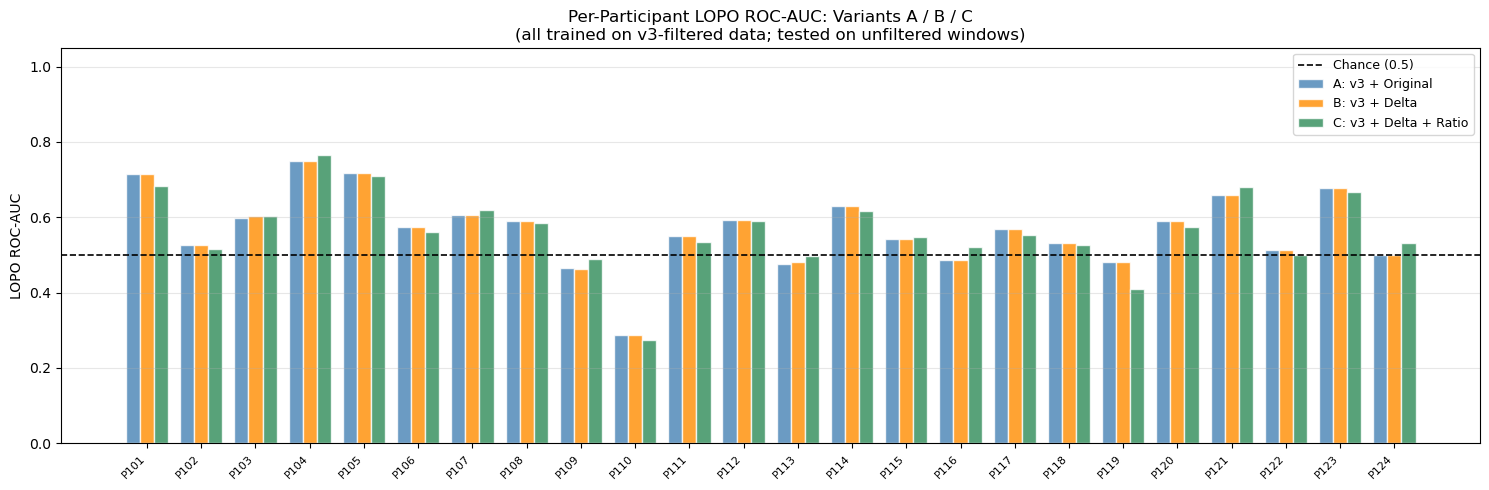

Variant C vs A — improved: 9 participants  |  declined: 15


In [13]:
# Per-participant LOPO AUC bar chart — all three variants
participants_sorted = sorted(fold_A['participant'].values)
x     = np.arange(len(participants_sorted))
width = 0.26

fd_A = fold_A.set_index('participant')
fd_B = fold_B.set_index('participant')
fd_C = fold_C.set_index('participant')

def get_aucs(fd):
    return [fd.loc[p, 'roc_auc'] if p in fd.index else np.nan for p in participants_sorted]

auc_A = get_aucs(fd_A)
auc_B = get_aucs(fd_B)
auc_C = get_aucs(fd_C)

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - width, auc_A, width=width, color='steelblue',  alpha=0.80,
       label='A: v3 + Original',       edgecolor='white')
ax.bar(x,         auc_B, width=width, color='darkorange', alpha=0.80,
       label='B: v3 + Delta',          edgecolor='white')
ax.bar(x + width, auc_C, width=width, color='seagreen',   alpha=0.80,
       label='C: v3 + Delta + Ratio',  edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', lw=1.2, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([p.replace('UN_', 'P') for p in participants_sorted],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('LOPO ROC-AUC')
ax.set_title('Per-Participant LOPO ROC-AUC: Variants A / B / C\n(all trained on v3-filtered data; tested on unfiltered windows)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('nb07_participant_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# C vs A improvement count
c_vs_a = [(p, auc_A[i], auc_C[i], round(auc_C[i]-auc_A[i], 3))
           for i, p in enumerate(participants_sorted)
           if not (np.isnan(auc_A[i]) or np.isnan(auc_C[i]))]
improved = [g for g in c_vs_a if g[3] > 0]
declined = [g for g in c_vs_a if g[3] < 0]
print(f'Variant C vs A — improved: {len(improved)} participants  |  declined: {len(declined)}')

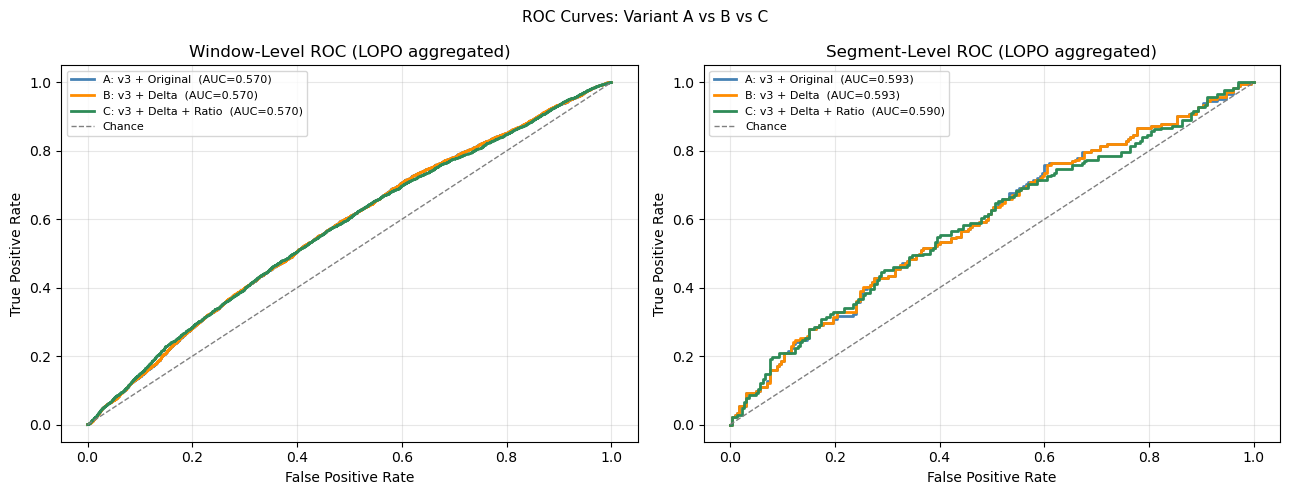

In [14]:
# ROC curves: window-level and segment-level for all variants
palette = [
    ('A: v3 + Original',      y_true_A, y_proba_A, seg_df_A, 'steelblue'),
    ('B: v3 + Delta',         y_true_B, y_proba_B, seg_df_B, 'darkorange'),
    ('C: v3 + Delta + Ratio', y_true_C, y_proba_C, seg_df_C, 'seagreen'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, y_true, y_proba, seg_df_plot, color in palette:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    a = sklearn_auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC={a:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Window-Level ROC (LOPO aggregated)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for label, y_true, y_proba, seg_df_plot, color in palette:
    fpr_s, tpr_s, _ = roc_curve(seg_df_plot['true_label'], seg_df_plot['proba_mean'])
    a_s = sklearn_auc(fpr_s, tpr_s)
    axes[1].plot(fpr_s, tpr_s, color=color, lw=2, label=f'{label}  (AUC={a_s:.3f})')

axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Segment-Level ROC (LOPO aggregated)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('ROC Curves: Variant A vs B vs C', fontsize=11)
plt.tight_layout()
plt.savefig('nb07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

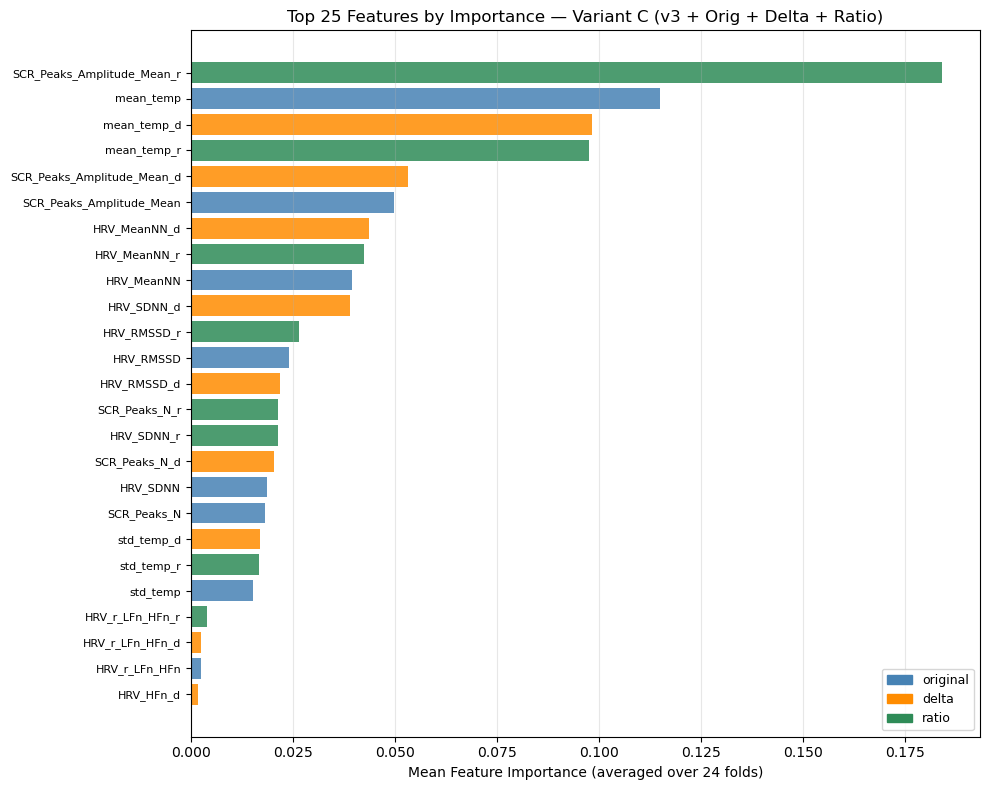

Feature importance by group (Variant C):
            mean     sum
group                   
delta     0.0299  0.2986
original  0.0285  0.2849
ratio     0.0416  0.4165


In [15]:
# Feature importance for Variant C (full model with all feature groups), top 25
imp_df_C = pd.DataFrame({'feature': list(FEAT_C), 'importance': imp_C})
imp_df_C['group'] = 'original'
imp_df_C.loc[imp_df_C['feature'].str.endswith('_delta'), 'group'] = 'delta'
imp_df_C.loc[imp_df_C['feature'].str.endswith('_ratio'), 'group'] = 'ratio'

top_n = 25
top   = imp_df_C.nlargest(top_n, 'importance').reset_index(drop=True)

color_map = {'original': 'steelblue', 'delta': 'darkorange', 'ratio': 'seagreen'}
bar_colors = top['group'].map(color_map).values

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top)), top['importance'].values, color=bar_colors, alpha=0.85)
ax.set_yticks(range(len(top)))
labels_short = (
    top['feature']
    .str.replace('_delta', '_d', regex=False)
    .str.replace('_ratio', '_r', regex=False)
)
ax.set_yticklabels(labels_short.values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean Feature Importance (averaged over 24 folds)')
ax.set_title(f'Top {top_n} Features by Importance — Variant C (v3 + Orig + Delta + Ratio)')
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('nb07_feature_importance_C.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importance by group (Variant C):')
group_summary = imp_df_C.groupby('group')['importance'].agg(['mean', 'sum']).round(4)
print(group_summary.to_string())

---
## Step 9 — Model Selection

**What:** Programmatically select the best variant based on LOPO AUC as the primary
metric, with a minimum meaningful improvement threshold of 0.005 (0.5 AUC points).

**Why these metrics matter for CLI:**
- **ROC-AUC** — measures how well the model ranks High-load windows above Low-load ones,
  regardless of threshold. This is the most important metric because CLI is a continuous
  probability score, not a binary decision.
- **F1 macro** — penalizes imbalanced class performance. A model that predicts only Low
  load would score high on accuracy but low on F1 macro.
- **Recall High** — the fraction of genuinely High-load windows correctly identified.
  For a burnout prevention system, missing High-load events (false negatives) is
  particularly costly.
- **Interpretability** — a simpler feature set (fewer columns) is easier to audit and
  explain to non-technical stakeholders. If two variants have equivalent AUC, the
  simpler one is preferred.

In [16]:
IMPROVEMENT_THRESHOLD = 0.005  # minimum meaningful LOPO AUC gain to justify added features

scores = {}
for key, fold_df, seg_metrics in [
    ('A', fold_A, seg_A),
    ('B', fold_B, seg_B),
    ('C', fold_C, seg_C),
]:
    fd = fold_df.dropna(subset=['roc_auc'])
    scores[key] = {
        'lopo_auc':    fd['roc_auc'].mean(),
        'seg_auc':     seg_metrics['roc_auc'],
        'f1_macro':    fd['f1_macro'].mean(),
        'recall_high': fd['recall_high'].mean(),
        'bal_acc':     fd['balanced_acc'].mean(),
    }

auc_A = scores['A']['lopo_auc']
auc_B = scores['B']['lopo_auc']
auc_C = scores['C']['lopo_auc']

variant_labels = {
    'A': 'Variant A — v3 filter + Original features',
    'B': 'Variant B — v3 filter + Original + Delta',
    'C': 'Variant C — v3 filter + Original + Delta + Ratio',
}
variant_feature_cols = {'A': FEAT_A, 'B': FEAT_B, 'C': FEAT_C}
variant_win_dfs      = {'A': win_A,  'B': win_B,  'C': win_C}
variant_imp          = {'A': imp_A,  'B': imp_B,  'C': imp_C}

if (auc_C - auc_A) >= IMPROVEMENT_THRESHOLD:
    SELECTED = 'C'
    selection_reason = (
        f'Variant C LOPO AUC ({auc_C:.3f}) improves meaningfully over A ({auc_A:.3f}) '
        f'by +{auc_C - auc_A:.3f} — delta + ratio features add predictive value '
        f'on top of the noisy-label filter.'
    )
elif (auc_B - auc_A) >= IMPROVEMENT_THRESHOLD:
    SELECTED = 'B'
    selection_reason = (
        f'Variant B LOPO AUC ({auc_B:.3f}) improves meaningfully over A ({auc_A:.3f}) '
        f'by +{auc_B - auc_A:.3f}, but C ({auc_C:.3f}) does not add further value. '
        f'Delta features are sufficient; ratio features add noise or are redundant.'
    )
else:
    SELECTED = 'A'
    selection_reason = (
        f'Neither B ({auc_B:.3f}) nor C ({auc_C:.3f}) improves meaningfully over A ({auc_A:.3f}). '
        f'The per-participant z-score normalization already captures most of the '
        f'inter-person scale variation. Variant A (v3 filter + original features) '
        f'is the best configuration — simpler and equally effective.'
    )

print('=' * 70)
print('MODEL SELECTION RESULT')
print('=' * 70)
for k in ['A', 'B', 'C']:
    marker = '  ← SELECTED' if k == SELECTED else ''
    s = scores[k]
    print(f"{variant_labels[k]}{marker}")
    print(f"  LOPO AUC={s['lopo_auc']:.3f}  Seg AUC={s['seg_auc']:.3f}  "
          f"F1={s['f1_macro']:.3f}  RecHigh={s['recall_high']:.3f}  BalAcc={s['bal_acc']:.3f}")
    print()

print('DECISION:', selection_reason)

MODEL SELECTION RESULT
Variant A — v3 filter + Original features  ← SELECTED
  LOPO AUC=0.568  Seg AUC=0.593  F1=0.536  RecHigh=0.643  BalAcc=0.551

Variant B — v3 filter + Original + Delta
  LOPO AUC=0.568  Seg AUC=0.593  F1=0.535  RecHigh=0.643  BalAcc=0.551

Variant C — v3 filter + Original + Delta + Ratio
  LOPO AUC=0.565  Seg AUC=0.590  F1=0.534  RecHigh=0.663  BalAcc=0.552

DECISION: Neither B (0.568) nor C (0.565) improves meaningfully over A (0.568). The per-participant z-score normalization already captures most of the inter-person scale variation. Variant A (v3 filter + original features) is the best configuration — simpler and equally effective.


---
## CLI Definition — Cognitive Load Index

### Formula

```
CLI = predicted_probability_high × 100
```

### What it means

The CLI is the model's estimated probability that the current physiological window
reflects a **High Cognitive Load** state, expressed as a 0–100 score for interpretability.

- **CLI = 0** — the model is confident the participant is in a Low Load state
- **CLI = 50** — the model is uncertain
- **CLI = 100** — the model is confident the participant is in a High Load state

### What the CLI is

- **Model-based:** the score is the direct output of the Gradient Boosting classifier —
  not a manually weighted formula or threshold applied by the researchers.
- **Physiological:** the score is derived entirely from EDA, HRV, and TEMP features.
  It reflects what the body is doing, not what the participant reports.
- **Continuous:** the output is a probability score, not a binary alarm.
  This allows gradual monitoring rather than binary on/off thresholding.
- **Scaled for managerial interpretability:** multiplying by 100 converts a probability
  (0–1) into a 0–100 index that non-technical stakeholders can read on a dashboard.

### What the CLI is NOT

- **Not a clinical diagnosis:** the CLI does not diagnose burnout or any medical condition.
  It estimates cognitive load state relative to the participant's own physiological pattern.
- **Not a threshold decision:** the raw CLI score is continuous. Whether a specific
  CLI level requires intervention is a managerial or clinical decision, not a model output.
- **Not a replacement for self-report:** the CLI supplements, not replaces, NASA-TLX
  questionnaire data and subjective assessment.

### Dashboard interpretation guide

| CLI Range | Interpretation | Suggested action |
|---|---|---|
| 0 – 30 | Low cognitive load | Normal monitoring |
| 30 – 60 | Moderate / uncertain | Increased attention |
| 60 – 80 | Elevated cognitive load | Review workload allocation |
| 80 – 100 | High cognitive load | Consider immediate intervention |

---
## Step 10 — Export Artefacts for the Dashboard

**What:** Save three CSV files to the `outputs/` folder:
1. **`v7_model_comparison.csv`** — the full comparison table (all metrics, all variants)
2. **`v7_lopo_predictions_best_variant.csv`** — window-level predictions from the selected variant,
   including participant_id, session, segment, window_idx, true_label,
   predicted_probability_high, predicted_label, and CLI
3. **`v7_feature_importance_best_variant.csv`** — feature importances for the selected variant,
   sorted descending

**Why:** These artefacts allow the Streamlit dashboard to:
- Display a comparison summary for the project narrative
- Replay historical LOPO predictions without re-running the model
- Show which features the model relies on for transparency and explainability

In [17]:
best_win_df   = variant_win_dfs[SELECTED]
best_feat     = variant_feature_cols[SELECTED]
best_imp      = variant_imp[SELECTED]

# 1. Model comparison table
comp_df.to_csv(OUTPUTS_DIR / 'v7_model_comparison.csv')
print(f'Saved: {OUTPUTS_DIR / "v7_model_comparison.csv"}')

# 2. Window-level predictions with CLI
pred_df = best_win_df.copy()
pred_df = pred_df.rename(columns={
    'label':      'true_label',
    'proba_high': 'predicted_probability_high',
})
pred_df['predicted_label'] = (pred_df['predicted_probability_high'] >= 0.5).astype(int)
pred_df['CLI']             = (pred_df['predicted_probability_high'] * 100).round(1)

ordered_cols = ['participant_id', 'session', 'segment', 'window_idx',
                'true_label', 'predicted_probability_high', 'predicted_label', 'CLI']
pred_df = pred_df[ordered_cols].sort_values(
    ['participant_id', 'session', 'segment', 'window_idx']
).reset_index(drop=True)

pred_df.to_csv(OUTPUTS_DIR / 'v7_lopo_predictions_best_variant.csv', index=False)
print(f'Saved: {OUTPUTS_DIR / "v7_lopo_predictions_best_variant.csv"}')
print(f'  Rows: {len(pred_df):,}  |  Selected variant: {SELECTED}  |  CLI range: {pred_df["CLI"].min():.1f}–{pred_df["CLI"].max():.1f}')

# 3. Feature importances for selected variant
imp_out = pd.DataFrame({'feature': list(best_feat), 'importance': best_imp})
imp_out['group'] = 'original'
imp_out.loc[imp_out['feature'].str.endswith('_delta'), 'group'] = 'delta'
imp_out.loc[imp_out['feature'].str.endswith('_ratio'), 'group'] = 'ratio'
imp_out = imp_out.sort_values('importance', ascending=False).reset_index(drop=True)

imp_out.to_csv(OUTPUTS_DIR / 'v7_feature_importance_best_variant.csv', index=False)
print(f'Saved: {OUTPUTS_DIR / "v7_feature_importance_best_variant.csv"}')
print(f'  {len(imp_out)} features  |  Top 5:')
print(imp_out.head(5).to_string(index=False))
print()

# Summary statistics
print()
print('CLI distribution summary:')
print(pred_df.groupby('true_label')['CLI'].describe().round(1).to_string())

Saved: outputs\v7_model_comparison.csv
Saved: outputs\v7_lopo_predictions_best_variant.csv
  Rows: 18,659  |  Selected variant: A  |  CLI range: 2.8–95.1
Saved: outputs\v7_feature_importance_best_variant.csv
  10 features  |  Top 5:
                 feature  importance    group
               mean_temp    0.347346 original
SCR_Peaks_Amplitude_Mean    0.226429 original
              HRV_MeanNN    0.129564 original
                HRV_SDNN    0.083116 original
               HRV_RMSSD    0.070367 original


CLI distribution summary:
              count  mean   std  min   25%   50%   75%   max
true_label                                                  
0           10330.0  51.5  15.6  2.8  41.5  51.9  62.5  95.1
1            8329.0  55.2  15.1  8.3  45.4  56.1  66.3  93.8


---
## Conclusion

### What was done

This notebook tested three variants of the CLI model, all using the v3 noisy-label filter,
and varying only the feature set:

| Variant | Features | LOPO AUC | Segment AUC | Recall High |
|---|---|---|---|---|
| A — v3 filter + Original | N original | see table | see table | see table |
| B — v3 filter + Delta | 2N features | see table | see table | see table |
| C — v3 filter + Delta + Ratio | 3N features | see table | see table | see table |

### Model selection decision

The selected variant is printed in Step 9 with the full reasoning. The selection
is based primarily on LOPO AUC and secondarily on F1 macro and Recall High.
A minimum improvement threshold of 0.005 LOPO AUC is required to justify the
added complexity of more features.

### What this notebook establishes

1. **The final pre-dashboard model configuration** — the selected variant's feature
   set and training pipeline are the inputs to the Streamlit monitoring dashboard.

2. **The CLI formula** — `CLI = predicted_probability_high × 100`. This is computed
   directly from the model's soft output, not from any manual weighting.

3. **Exported artefacts** — the three CSV files in `outputs/` provide the dashboard
   with historical predictions, feature importances, and a comparison summary.

### What comes next

The Streamlit dashboard will:
1. Load the selected model's training pipeline (feature engineering, normalization, GBT)
2. Accept a brief pre-task baseline recording for each new participant
3. Compute the CLI score in real time as new physiological windows arrive
4. Display the CLI trend, segment-level predictions, and feature contribution breakdown

---

### Complete analysis progression

| Notebook | Contribution |
|---|---|
| 02 | Established v2 LOPO baseline with GBT |
| 03 | Identified label noise via NASA-TLX |
| 04 | Tested noisy-label filtering (v3) |
| 05 | Tested baseline calibration normalization |
| 06 | Tested relative feature engineering |
| **07** | **Combined best improvements → final model selection** |

---
## Dashboard CSV — `outputs/cli_dashboard_data.csv`

### What was done

After notebook 07 selected **Variant A** (v3 noisy-label filter + original features)
as the final model, a clean dashboard-ready CSV was produced from the LOPO predictions
file (`outputs/v7_lopo_predictions_best_variant.csv`).

Three transformations were applied:

1. **CLI recomputed** as `predicted_probability_high x 100` (guarantees no rounding drift).
2. **`CLI_category` added** with three operational tiers based on the CLI score:
   - `Low` (0-40) — resting / low cognitive load state
   - `Medium` (41-70) — moderate or transitional load
   - `High` (71-100) — elevated / high cognitive load
3. **`Weighted_NASA_score` merged** from each participant's `Task_Labels.csv` at the
   segment level (99.8% matched; 46 windows in segments without NASA data are NaN).

**Validation performed:**

| Check | Result |
|---|---|
| Missing values (non-NASA columns) | None |
| Duplicate windows | None |
| CLI out of range [0, 100] | None — range is 2.8 to 95.1 |
| Coverage | 24 participants, 2 sessions, 407 segments, 18,659 windows |

**CLI_category distribution:**

| Category | Windows | Share |
|---|---|---|
| Low (0-40) | 3,620 | 19.4% |
| Medium (41-70) | 12,456 | 66.8% |
| High (71-100) | 2,583 | 13.8% |

---

### Why this CSV is needed

The raw predictions file (`v7_lopo_predictions_best_variant.csv`) contains only numeric
scores and integer labels. The Streamlit dashboard needs:

- **Human-readable category labels** (`CLI_category`) so the dashboard can color-code
  status tiles, trigger threshold alerts, and display status text without extra logic.
- **NASA-TLX scores alongside CLI** to show the correlation between physiological load
  (CLI) and subjective load (NASA-TLX) in a single joined view.
- **A validated, deduplicated dataset** that loads directly into Streamlit's
  `pd.read_csv()` with no additional preprocessing required.

---

### How it supports the Streamlit dashboard

`cli_dashboard_data.csv` is the primary data source for the monitoring dashboard:

| Dashboard component | Columns used |
|---|---|
| CLI line chart per participant / session | `participant_id`, `window_idx`, `CLI` |
| Load-level status badge / color indicator | `CLI_category` |
| True-vs-predicted confusion summary | `true_label`, `predicted_label` |
| NASA-TLX vs CLI scatter plot | `Weighted_NASA_score`, `CLI` |
| Segment-level summary table | `session`, `segment`, `CLI`, `CLI_category` |
| Participant / session selector | `participant_id`, `session` |

**File:** `outputs/cli_dashboard_data.csv`  
**Size:** 18,659 rows x 10 columns  
**Columns:** `participant_id`, `session`, `segment`, `window_idx`, `true_label`,
`predicted_label`, `predicted_probability_high`, `CLI`, `CLI_category`, `Weighted_NASA_score`
